# Online Learning

Online learning is a machine learning paradigm in which a model learns
incrementally from data as observations become available.

Unlike batch learning, where a model is trained on the entire dataset at once,
online learning updates the model continuously using individual observations
or small batches of observations.

This makes online learning particularly useful for:

- Streaming data
- Real-time prediction
- Large datasets
- Non-stationary environments
- Systems where storing the entire dataset is impractical
- Applications where the model must adapt to changing patterns

Examples include:

- Fraud detection
- Recommendation systems
- Network monitoring
- Stock and demand prediction
- Sensor systems
- Click-through-rate prediction
- Real-time anomaly detection

## What Is Online Learning?

Suppose observations arrive sequentially:

$$
(x_1, y_1), (x_2, y_2), \ldots, (x_t, y_t), \ldots
$$

Instead of waiting until all observations are available, an online learning
algorithm updates its model whenever new observations arrive.

At time $t$, the model has parameters:

$$
\theta_t
$$

After observing a new training example $(x_t, y_t)$, the parameters are
updated:

$$
\theta_{t+1}
=
\theta_t
-
\eta_t \nabla_\theta L(\theta_t; x_t, y_t)
$$

where:

- $\theta_t$ is the current parameter vector
- $\eta_t$ is the learning rate
- $L$ is the loss function
- $\nabla_\theta L$ is the gradient of the loss

The important idea is that the model does **not need to retrain from scratch**
when new data arrives.

## Batch Learning vs Online Learning

### Batch Learning

A batch learning algorithm receives a dataset:

$$
D = \{(x_i, y_i)\}_{i=1}^{n}
$$

and learns a model using the complete dataset.

Conceptually:

$$
D
\rightarrow
\text{Training}
\rightarrow
\text{Model}
$$

If new data arrives, the model may need to be retrained.

### Online Learning

Online learning processes observations sequentially:

$$
(x_1,y_1)
\rightarrow
\theta_1
$$

$$
(x_2,y_2)
\rightarrow
\theta_2
$$

$$
(x_3,y_3)
\rightarrow
\theta_3
$$

and so on.

The model continuously adapts as new observations arrive.

### Main Difference

| Batch Learning | Online Learning |
|---|---|
| Learns from complete datasets | Learns incrementally |
| Usually requires more memory | Can use very little memory |
| Retraining may be expensive | Updates are inexpensive |
| Suitable for static datasets | Suitable for streaming data |
| Usually assumes more stable data | Can adapt to changing data |

## Simple Visualization

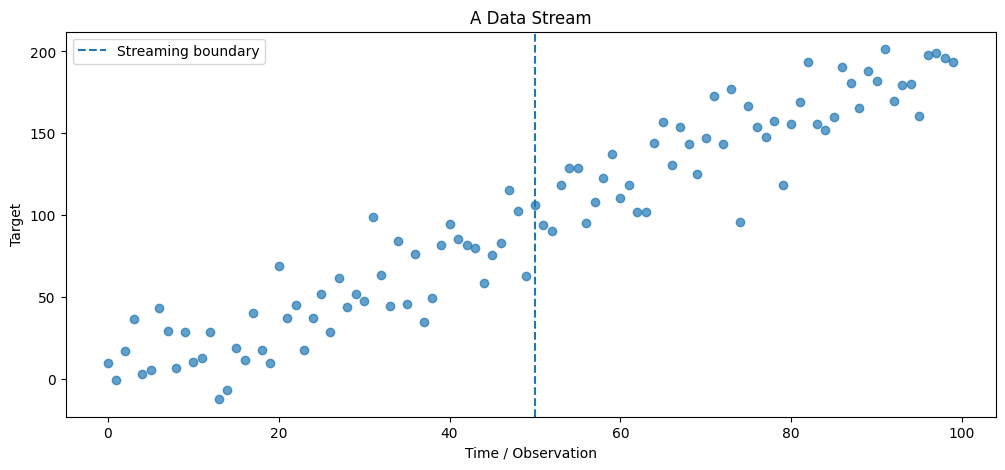

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_samples = 100

x = np.arange(n_samples)

# Simulated stream
y = 2 * x + np.random.normal(0, 20, n_samples)

plt.figure(figsize=(12, 5))

plt.scatter(x, y, alpha=0.7)

plt.axvline(
    50,
    linestyle="--",
    label="Streaming boundary"
)

plt.xlabel("Time / Observation")
plt.ylabel("Target")
plt.title("A Data Stream")

plt.legend()
plt.show()

## Incremental Gradient Descent

Consider a simple linear model:

$$
\hat{y} = wx + b
$$

For one observation $(x_t, y_t)$, use the squared-error loss:

$$
L_t
=
\frac{1}{2}
(\hat{y}_t-y_t)^2
$$

Since

$$
\hat{y}_t = wx_t+b
$$

the gradients are:

$$
\frac{\partial L_t}{\partial w}
=
(\hat{y}_t-y_t)x_t
$$

and

$$
\frac{\partial L_t}{\partial b}
=
\hat{y}_t-y_t
$$

Therefore:

$$
w_{t+1}
=
w_t
-
\eta
(\hat{y}_t-y_t)x_t
$$

$$
b_{t+1}
=
b_t
-
\eta
(\hat{y}_t-y_t)
$$

This is the basic mechanism behind many online optimization algorithms.

In [2]:
class OnlineLinearRegression:
    def __init__(self, learning_rate=0.001):
        self.learning_rate = learning_rate
        self.w = 0.0
        self.b = 0.0

    def partial_fit(self, x, y):
        prediction = self.w * x + self.b
        error = prediction - y

        self.w -= self.learning_rate * error * x
        self.b -= self.learning_rate * error

        return prediction

    def predict(self, x):
        return self.w * x + self.b

## Train the Online Model

In [3]:
np.random.seed(42)

x_stream = np.linspace(0, 10, 200)
y_stream = 3 * x_stream + 5 + np.random.normal(0, 1, 200)

model = OnlineLinearRegression(learning_rate=0.01)

weights = []
biases = []
predictions = []

for x_i, y_i in zip(x_stream, y_stream):
    prediction = model.partial_fit(x_i, y_i)

    predictions.append(prediction)
    weights.append(model.w)
    biases.append(model.b)

print(f"Final weight: {model.w:.4f}")
print(f"Final bias: {model.b:.4f}")

Final weight: 3.1100
Final bias: 2.7448


## Parameter Evolution

This visualization is important because it shows what online learning is actually doing internally.

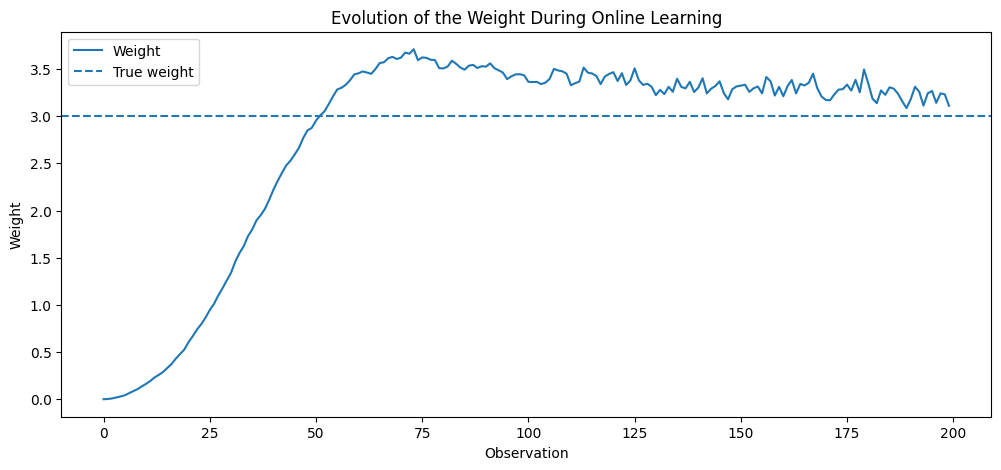

In [4]:
plt.figure(figsize=(12, 5))

plt.plot(weights, label="Weight")

plt.axhline(
    3,
    linestyle="--",
    label="True weight"
)

plt.xlabel("Observation")
plt.ylabel("Weight")
plt.title("Evolution of the Weight During Online Learning")

plt.legend()
plt.show()

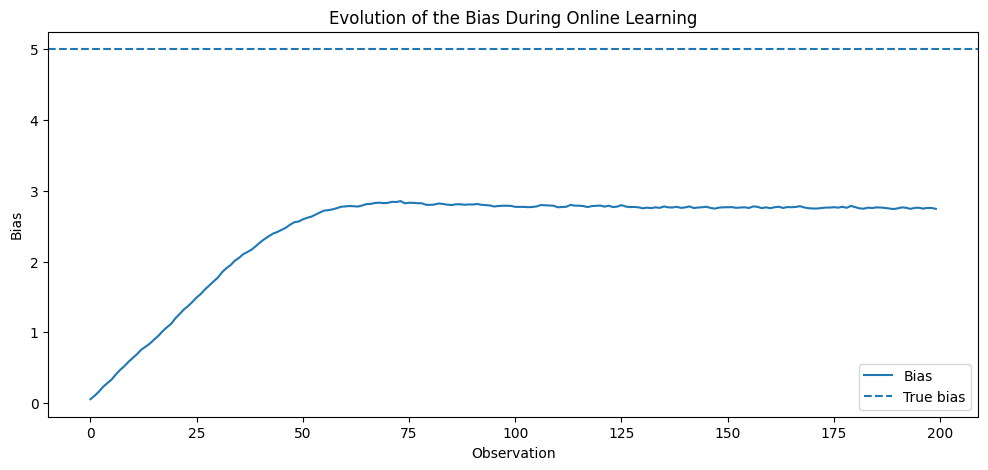

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(biases, label="Bias")

plt.axhline(
    5,
    linestyle="--",
    label="True bias"
)

plt.xlabel("Observation")
plt.ylabel("Bias")
plt.title("Evolution of the Bias During Online Learning")

plt.legend()
plt.show()

## Online Predictions

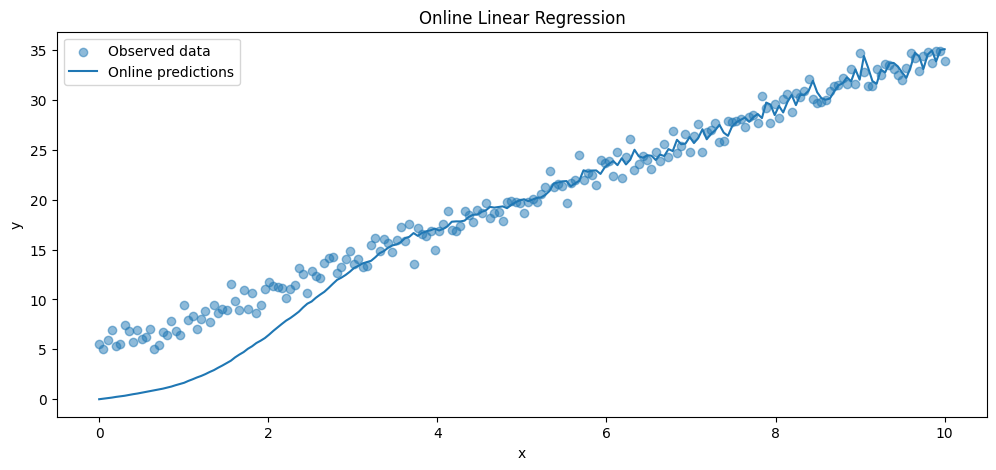

In [6]:
plt.figure(figsize=(12, 5))

plt.scatter(
    x_stream,
    y_stream,
    alpha=0.5,
    label="Observed data"
)

plt.plot(
    x_stream,
    predictions,
    label="Online predictions"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Online Linear Regression")

plt.legend()
plt.show()

## Online Logistic Regression

For binary classification, logistic regression estimates:

$$
P(y=1|x)
=
\sigma(w^Tx+b)
$$

where the sigmoid function is:

$$
\sigma(z)
=
\frac{1}{1+e^{-z}}
$$

For a single observation, the binary cross-entropy loss is:

$$
L
=
-
\left[
y\log(\hat{p})
+
(1-y)\log(1-\hat{p})
\right]
$$

The online update becomes:

$$
w_{t+1}
=
w_t
-
\eta_t
(\hat{p}_t-y_t)x_t
$$

and

$$
b_{t+1}
=
b_t
-
\eta_t
(\hat{p}_t-y_t)
$$

Thus logistic regression can also be trained incrementally.

## SGDClassifier

Now use a production-quality implementation.

In [7]:
from sklearn.datasets import make_classification
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

online_model = SGDClassifier(
    loss="log_loss",
    learning_rate="optimal",
    random_state=42
)

classes = np.unique(y_train)

for i in range(0, len(X_train), 32):
    X_batch = X_train[i:i+32]
    y_batch = y_train[i:i+32]

    online_model.partial_fit(
        X_batch,
        y_batch,
        classes=classes
    )

y_pred = online_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Online model accuracy: {accuracy:.4f}")

Online model accuracy: 0.7140


The key method here is:

partial_fit()

rather than:

fit()

## Incremental Updates with `partial_fit()`

`partial_fit()` allows a model to learn from successive chunks of data.

For example:

$$
D_1
\rightarrow
\text{Model}_1
$$

$$
D_2
\rightarrow
\text{Model}_2
$$

$$
D_3
\rightarrow
\text{Model}_3
$$

without restarting training from scratch.

This is particularly useful when:

- Data arrives continuously
- The dataset is too large for memory
- New observations arrive after deployment
- The underlying data distribution changes

## Streaming Data Simulation

In [8]:
from sklearn.datasets import make_classification

X_stream, y_stream = make_classification(
    n_samples=3000,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    random_state=42
)

batch_size = 50

model = SGDClassifier(
    loss="log_loss",
    random_state=42
)

classes = np.unique(y_stream)

accuracies = []

for start in range(0, len(X_stream), batch_size):

    end = start + batch_size

    X_batch = X_stream[start:end]
    y_batch = y_stream[start:end]

    model.partial_fit(
        X_batch,
        y_batch,
        classes=classes
    )

    predictions = model.predict(X_batch)

    batch_accuracy = accuracy_score(
        y_batch,
        predictions
    )

    accuracies.append(batch_accuracy)

## Progressive / Prequential Validation

In ordinary supervised learning, we often train on one dataset and evaluate
on another.

Streaming learning requires a different evaluation strategy.

A common approach is **progressive validation**, also called
**prequential evaluation**.

For each incoming observation:

1. Predict using the current model.
2. Observe the true target.
3. Update the model.

Conceptually:

$$
\text{Predict}
\rightarrow
\text{Observe label}
\rightarrow
\text{Update}
\rightarrow
\text{Next observation}
$$

This better reflects how an online model behaves after deployment.

In [9]:
model = SGDClassifier(
    loss="log_loss",
    random_state=42
)

classes = np.unique(y_stream)

progressive_accuracy = []

correct = 0

for i in range(len(X_stream)):

    x_i = X_stream[i:i+1]
    y_i = y_stream[i:i+1]

    if i == 0:
        model.partial_fit(
            x_i,
            y_i,
            classes=classes
        )
        continue

    prediction = model.predict(x_i)[0]

    correct += int(prediction == y_i[0])

    progressive_accuracy.append(
        correct / i
    )

    model.partial_fit(
        x_i,
        y_i
    )

## Plot Progressive Accuracy

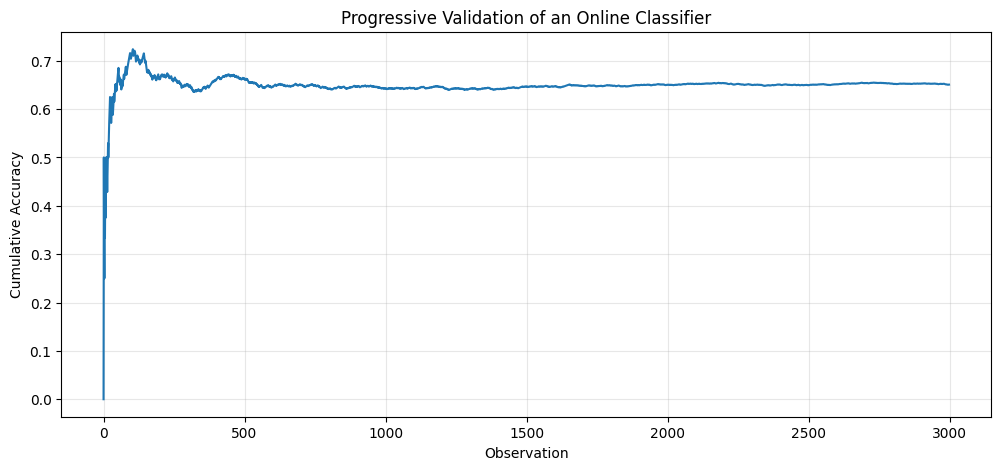

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(progressive_accuracy)

plt.xlabel("Observation")
plt.ylabel("Cumulative Accuracy")
plt.title("Progressive Validation of an Online Classifier")

plt.grid(alpha=0.3)
plt.show()

## Concept Drift

In many real-world streaming systems, the relationship between features and
the target changes over time.

This is called **concept drift**.

Suppose:

$$
P_t(X,Y)
\neq
P_{t+1}(X,Y)
$$

The data-generating process has changed.

Examples:

- Customer preferences change
- Fraud patterns evolve
- Demand changes with seasons
- User behavior changes
- Sensor characteristics change

A model trained on historical data may therefore become less accurate.

Online learning can continuously update the model to adapt to these changes.

## Simulate Concept Drift

In [11]:
np.random.seed(42)

n = 2000

x = np.random.randn(n, 2)

y = np.zeros(n, dtype=int)

# Concept 1
y[:1000] = (
    x[:1000, 0] + x[:1000, 1] > 0
).astype(int)

# Concept 2
y[1000:] = (
    x[1000:, 0] - x[1000:, 1] > 0
).astype(int)

In [12]:
model = SGDClassifier(
    loss="log_loss",
    random_state=42
)

classes = np.array([0, 1])

accuracies = []

for i in range(n):

    if i == 0:
        model.partial_fit(
            x[i:i+1],
            y[i:i+1],
            classes=classes
        )
        continue

    prediction = model.predict(x[i:i+1])[0]

    accuracies.append(
        int(prediction == y[i])
    )

    model.partial_fit(
        x[i:i+1],
        y[i:i+1]
    )

rolling_accuracy = (
    np.convolve(
        accuracies,
        np.ones(100) / 100,
        mode="valid"
    )
)

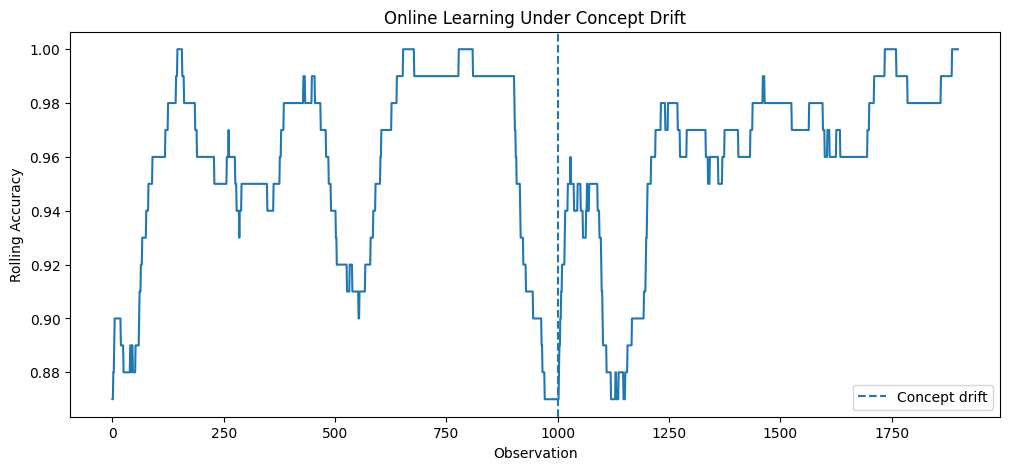

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(rolling_accuracy)

plt.axvline(
    1000,
    linestyle="--",
    label="Concept drift"
)

plt.xlabel("Observation")
plt.ylabel("Rolling Accuracy")
plt.title("Online Learning Under Concept Drift")

plt.legend()
plt.show()

## Forgetting Old Information

When the environment changes, old observations may become less useful.

One strategy is to train using only a recent window of observations.

For a window size $W$:

$$
D_t
=
\{
(x_{t-W+1},y_{t-W+1}),
\ldots,
(x_t,y_t)
\}
$$

The model therefore focuses more strongly on recent data.

Another strategy is to use a learning algorithm whose updates naturally
reduce the influence of older observations.

This creates a fundamental trade-off:

$$
\text{Stability}
\quad \leftrightarrow \quad
\text{Adaptability}
$$

## Learning Rate

The learning rate determines how strongly each new observation changes the
model.

The update is:

$$
\theta_{t+1}
=
\theta_t
-
\eta_t g_t
$$

where $g_t$ is the gradient.

A very large learning rate can cause unstable updates:

$$
\eta_t \uparrow
\Rightarrow
\text{faster but potentially unstable learning}
$$

A very small learning rate can make adaptation too slow:

$$
\eta_t \downarrow
\Rightarrow
\text{stable but slow adaptation}
$$

In non-stationary environments, this becomes particularly important because
the model must balance learning from new information against retaining useful
historical knowledge.

## Compare Learning Rates

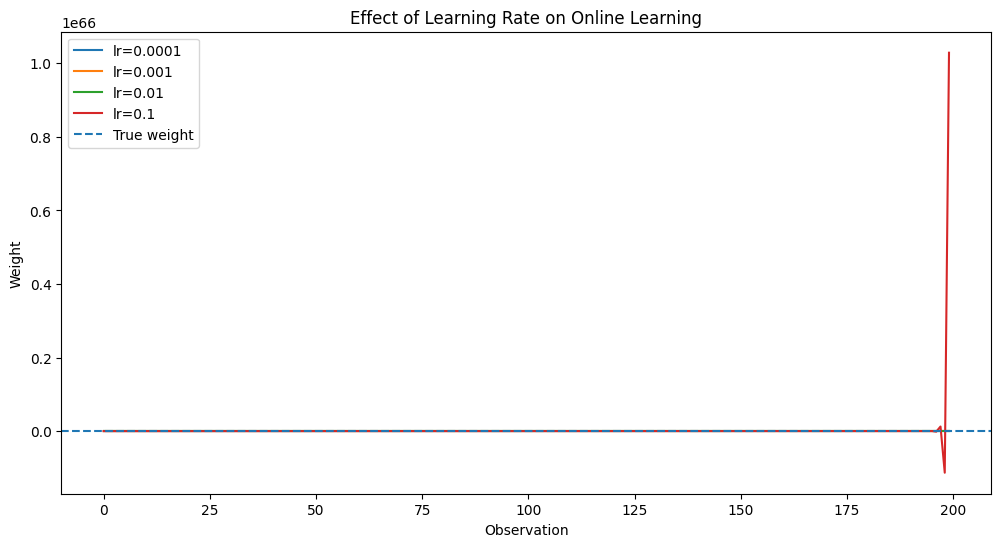

In [14]:
learning_rates = [
    0.0001,
    0.001,
    0.01,
    0.1
]

plt.figure(figsize=(12, 6))

for lr in learning_rates:

    model = OnlineLinearRegression(
        learning_rate=lr
    )

    weight_history = []

    for x_i, y_i in zip(x_stream, y_stream):

        model.partial_fit(x_i, y_i)

        weight_history.append(model.w)

    plt.plot(
        weight_history,
        label=f"lr={lr}"
    )

plt.axhline(
    3,
    linestyle="--",
    label="True weight"
)

plt.xlabel("Observation")
plt.ylabel("Weight")
plt.title("Effect of Learning Rate on Online Learning")

plt.legend()
plt.show()

## Batch Learning vs Online Learning

We can compare two approaches:

### Batch approach

Train once using the available training dataset.

### Online approach

Process observations sequentially using incremental updates.

The comparison should consider:

- Predictive performance
- Memory requirements
- Training time
- Adaptation to new data
- Behavior under concept drift

## Advantages

- Handles continuously arriving data
- Low memory requirements
- Can scale to very large datasets
- Can adapt to changing distributions
- Useful for real-time systems
- Avoids complete retraining

## Limitations

- Sensitive to learning-rate choices
- Can be affected by noisy observations
- Order of observations can matter
- Difficult to reproduce exactly in some streaming settings
- Concept drift can destabilize the model
- Some batch algorithms do not support incremental updates

## When Should We Use Online Learning?

Online learning is a strong choice when at least one of the following is true:

1. Data arrives continuously.
2. The dataset is too large to process as a single batch.
3. Predictions must be updated frequently.
4. The underlying data distribution changes.
5. Storing all historical data is expensive or unnecessary.

Examples:

| Application | Why Online Learning? |
|---|---|
| Fraud detection | Fraud patterns evolve |
| Recommendation systems | User preferences change |
| Network monitoring | Traffic patterns change |
| Demand forecasting | Demand evolves over time |
| Sensor systems | Continuous observations |
| Advertising | User behavior changes rapidly |

# Key Takeaways

- Online learning updates a model incrementally.
- The fundamental update is based on a gradient step:

$$
\theta_{t+1}
=
\theta_t
-
\eta_t\nabla_\theta L_t
$$

- `partial_fit()` is an important mechanism for incremental learning in
  scikit-learn.
- Progressive validation evaluates models in a realistic streaming setting.
- Concept drift occurs when the underlying data-generating process changes.
- Online models can adapt to concept drift.
- Learning rate controls the balance between stability and adaptation.
- Sliding windows and forgetting mechanisms can reduce the influence of
  outdated information.
- Online learning is particularly useful for streaming, large-scale, and
  non-stationary problems.

The central idea is:

$$
\boxed{
\text{Predict}
\rightarrow
\text{Observe}
\rightarrow
\text{Update}
\rightarrow
\text{Repeat}
}
$$